# Understanding data

In [1]:
import sklearn
print(sklearn.__version__)

1.6.1


In [2]:
import sys
print(f"Python Version: {sys.version}")

Python Version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [3]:
import numpy
print(f"Numpy Version: {numpy.__version__}")

Numpy Version: 2.0.2


In [4]:
get_ipython().system('pip install pandas==2.2.2')

In [5]:
get_ipython().system('pip install numpy==2.0.2')

In [6]:
get_ipython().system('pip install scikit-learn==1.6.1')

In [7]:
import pandas
print(f"Pandas Version: {pandas.__version__}")

Pandas Version: 2.2.2


In [8]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import PowerTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix,classification_report



In [9]:
data=pd.read_csv('heart.csv')

In [10]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [11]:
data.shape

(1025, 14)

In [12]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [13]:
data.duplicated().sum()

np.int64(723)

In [14]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [16]:
data['sex'].value_counts()

,count
sex,
1,713
0,312


In [17]:
data['cp'].value_counts()

,count
cp,
0,497
2,284
1,167
3,77


In [18]:
data['fbs'].value_counts()

,count
fbs,
0,872
1,153


In [19]:
data['restecg'].value_counts()

,count
restecg,
1,513
0,497
2,15


In [20]:
data['exang'].value_counts()

,count
exang,
0,680
1,345


In [21]:
data['slope'].value_counts()

,count
slope,
1,482
2,469
0,74


In [22]:
data['ca'].value_counts()

,count
ca,
0,578
1,226
2,134
3,69
4,18


# Plotting graphs

# Univariate analysis on Categorical data

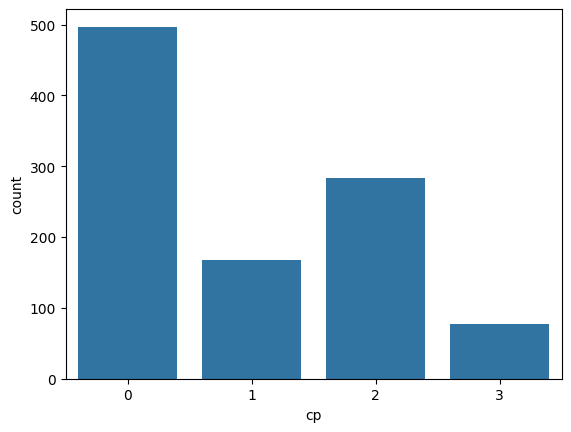

In [23]:
sns.countplot(data=data,x='cp')
plt.show()

<Axes: xlabel='sex', ylabel='count'>

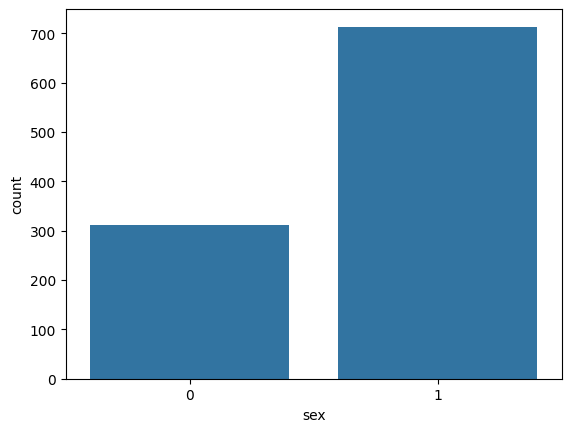

In [24]:
sns.countplot(x='sex',data=data)

<Axes: xlabel='fbs', ylabel='count'>

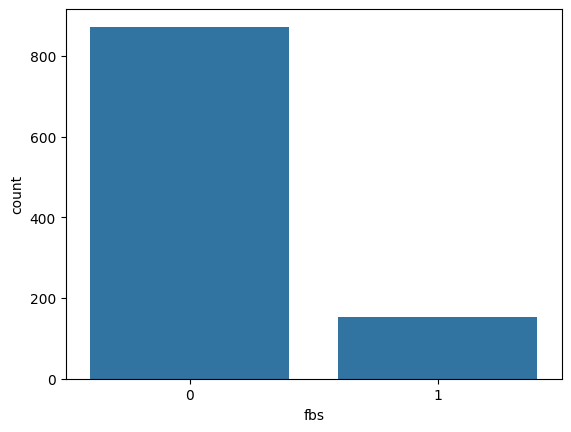

In [25]:
sns.countplot(x='fbs',data=data)

<Axes: xlabel='restecg', ylabel='count'>

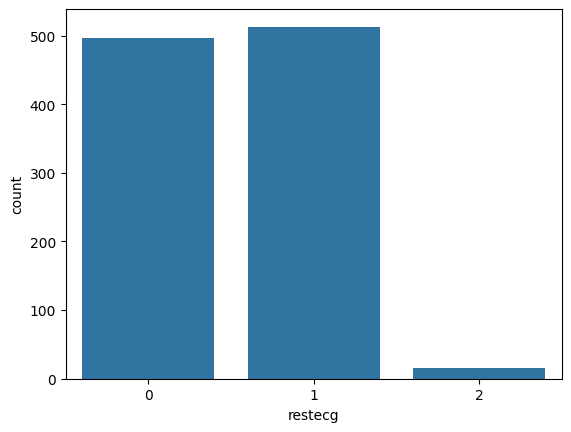

In [26]:
sns.countplot(x='restecg',data=data)

<Axes: xlabel='exang', ylabel='count'>

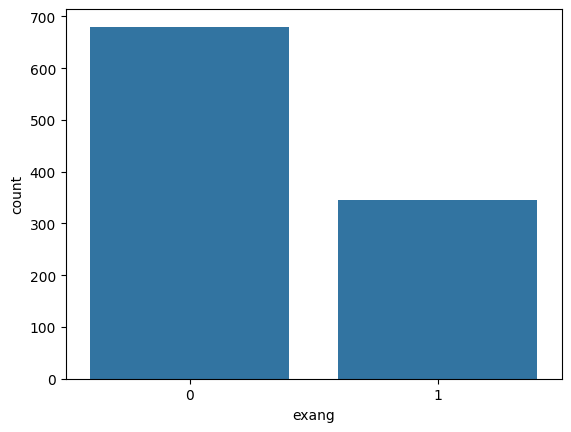

In [27]:
sns.countplot(x='exang',data=data)

<Axes: xlabel='slope', ylabel='count'>

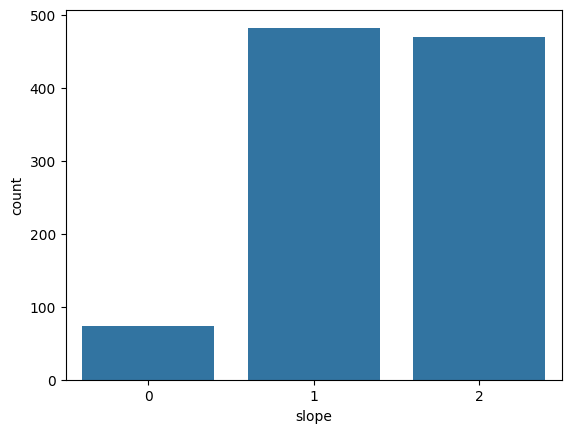

In [28]:
sns.countplot(x='slope',data=data)

<Axes: xlabel='ca', ylabel='count'>

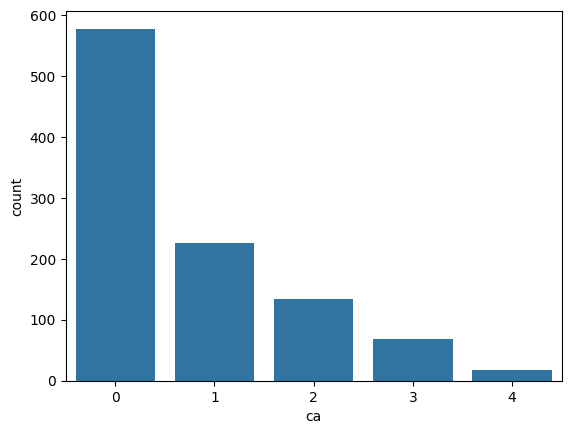

In [29]:
sns.countplot(x='ca',data=data)

<Axes: xlabel='thal', ylabel='count'>

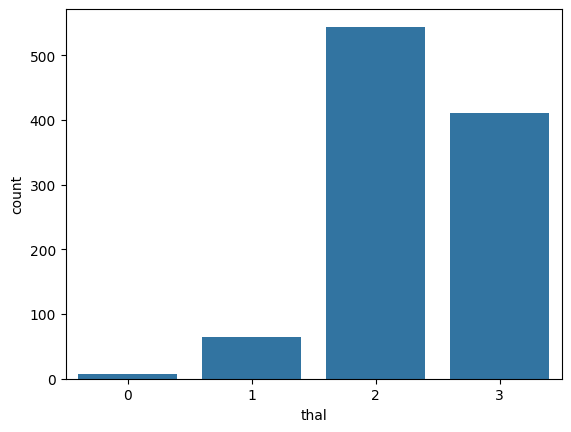

In [30]:
sns.countplot(x='thal',data=data)

# Univariate analysis on numerical data

<Axes: xlabel='age', ylabel='Density'>

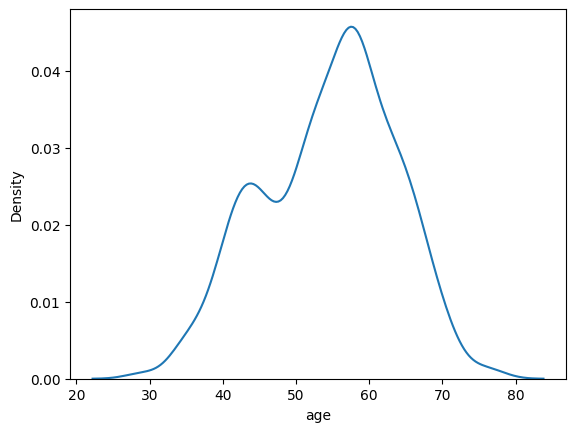

In [31]:
sns.kdeplot(data=data,x='age')

In [32]:
data['age'].skew()

np.float64(-0.24886590174584555)

<Axes: xlabel='trestbps', ylabel='Density'>

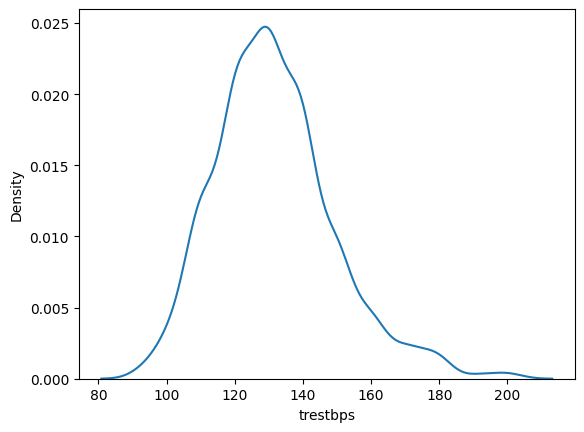

In [33]:
sns.kdeplot(data=data,x='trestbps')

In [34]:
data['trestbps'].skew()

np.float64(0.739768226050074)

<Axes: xlabel='chol', ylabel='Density'>

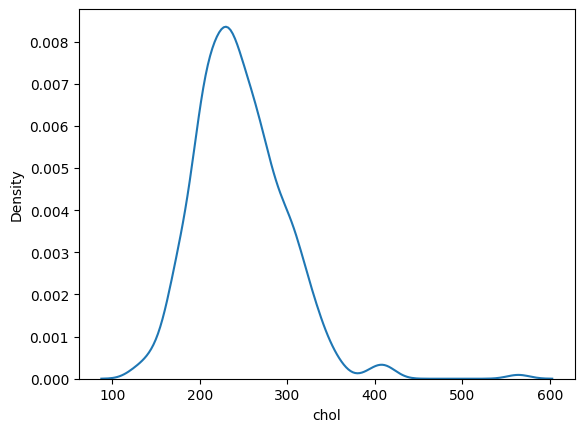

In [35]:
sns.kdeplot(data=data,x='chol')

In [36]:
data['chol'].skew()

np.float64(1.0740727783354815)

<Axes: xlabel='thalach', ylabel='Density'>

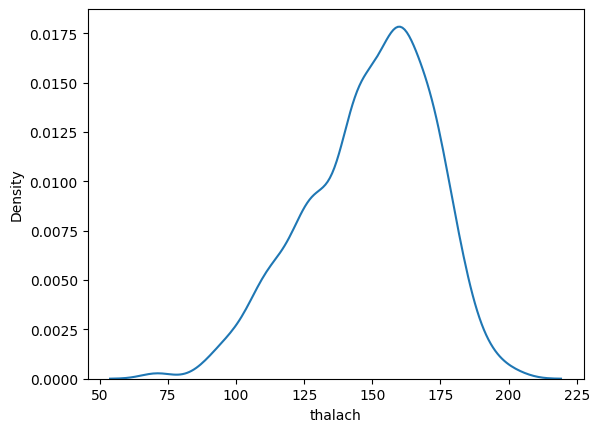

In [37]:
sns.kdeplot(data=data,x='thalach')

In [38]:
data['thalach'].skew()

np.float64(-0.5137771771417209)

<Axes: xlabel='oldpeak', ylabel='Density'>

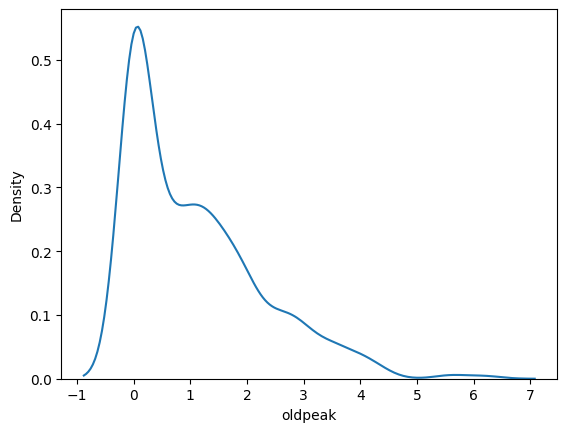

In [39]:
sns.kdeplot(data=data,x='oldpeak')

In [40]:
data['oldpeak'].skew()

np.float64(1.2108993882065326)

# Bivariate analysis

<Axes: xlabel='sex', ylabel='target'>

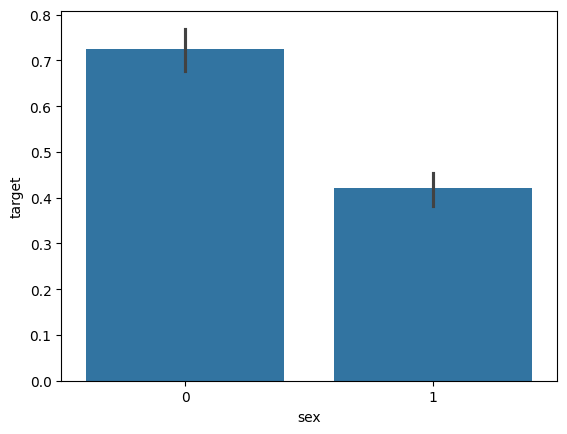

In [41]:
sns.barplot(x=data['sex'],y=data['target'])

<Axes: xlabel='cp', ylabel='target'>

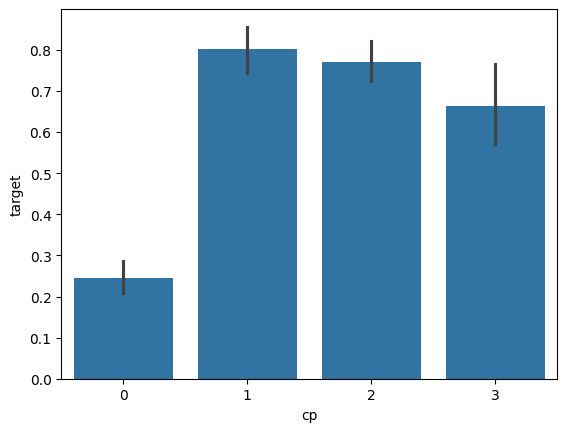

In [42]:
sns.barplot(x=data['cp'],y=data['target'])

<Axes: xlabel='fbs', ylabel='target'>

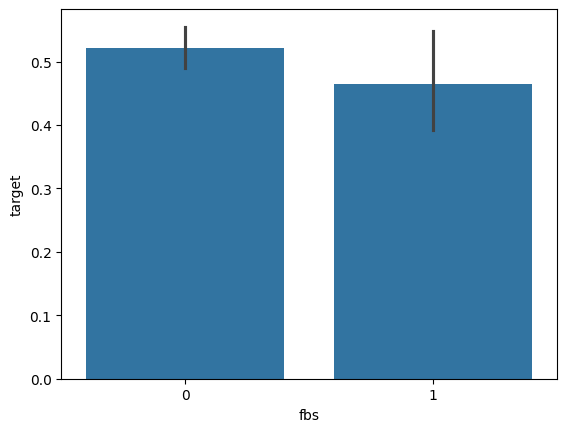

In [43]:
sns.barplot(x=data['fbs'],y=data['target'])

<Axes: xlabel='restecg', ylabel='target'>

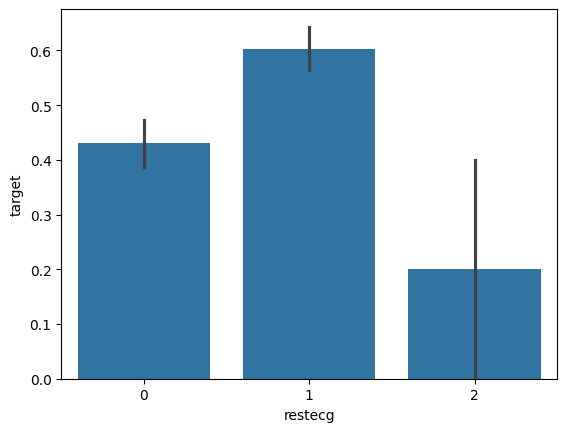

In [44]:
sns.barplot(x=data['restecg'],y=data['target'])

<Axes: xlabel='exang', ylabel='target'>

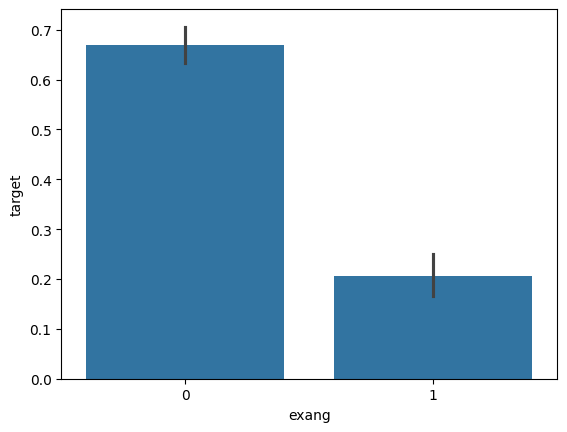

In [45]:
sns.barplot(x=data['exang'],y=data['target'])

<Axes: xlabel='slope', ylabel='target'>

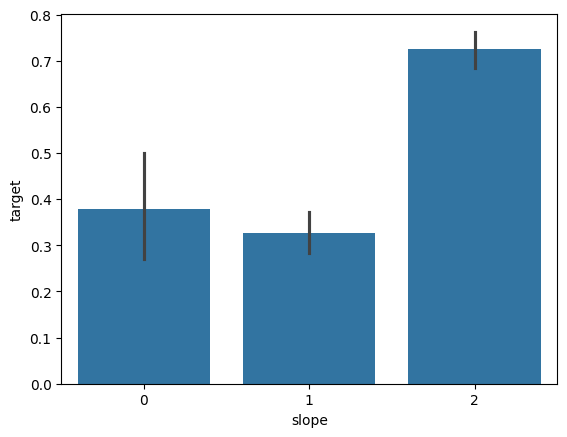

In [46]:
sns.barplot(x=data['slope'],y=data['target'])

<Axes: xlabel='ca', ylabel='target'>

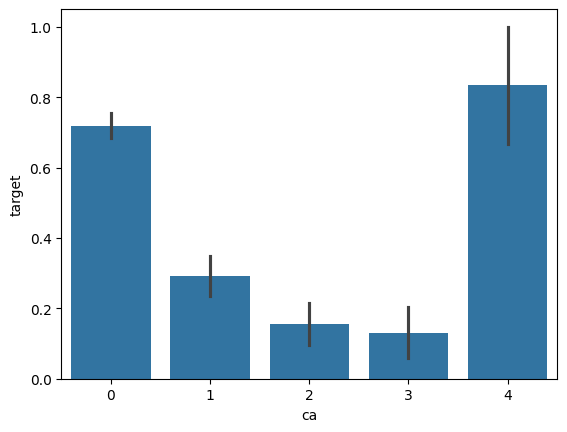

In [47]:
sns.barplot(x=data['ca'],y=data['target'])

<Axes: xlabel='thal', ylabel='target'>

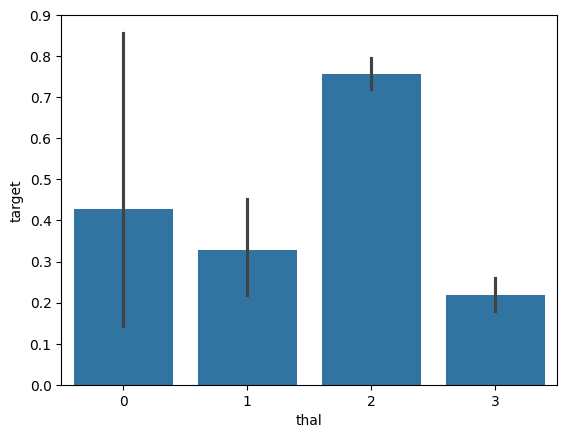

In [48]:
sns.barplot(x=data['thal'],y=data['target'])

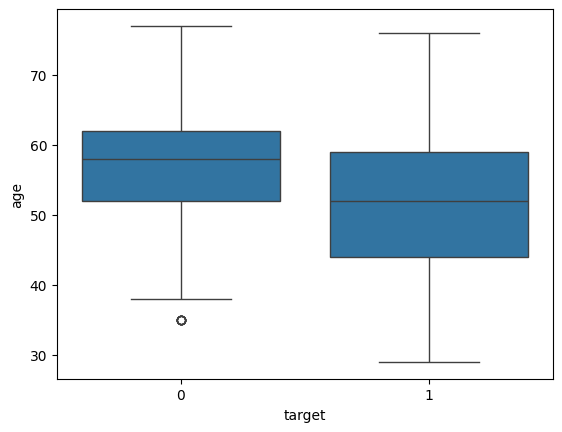

In [49]:
sns.boxplot(x=data['target'],y=data['age'])
plt.show()

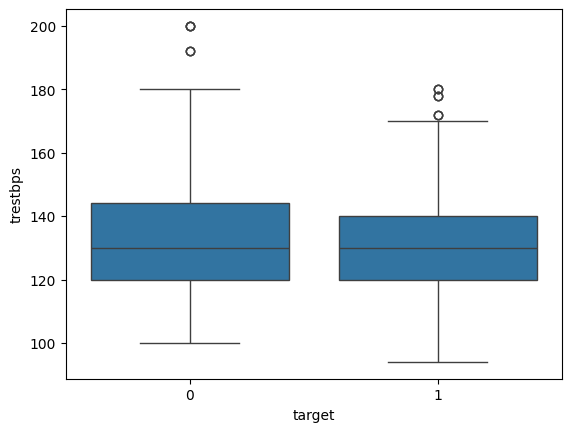

In [50]:
sns.boxplot(x=data['target'],y=data['trestbps'])
plt.show()

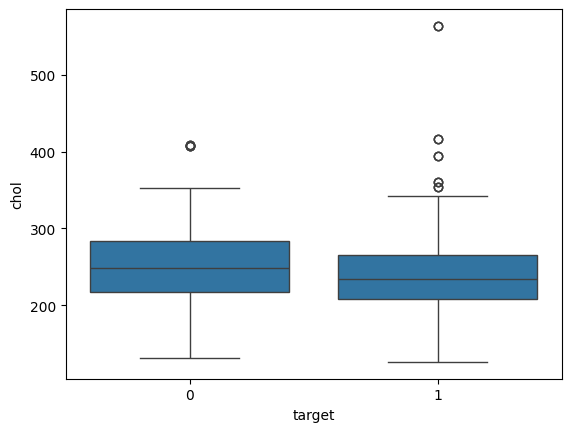

In [51]:
sns.boxplot(x=data['target'],y=data['chol'])
plt.show()

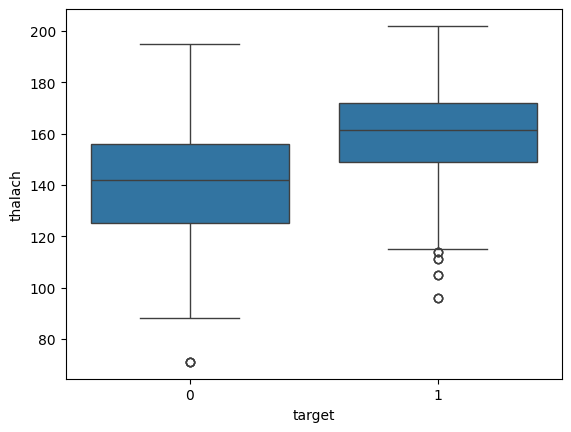

In [52]:
sns.boxplot(x=data['target'],y=data['thalach'])
plt.show()

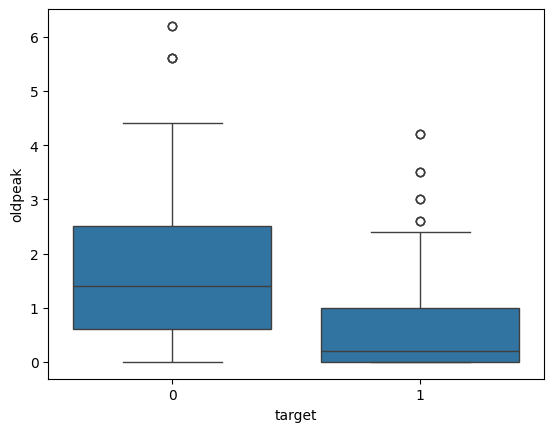

In [53]:
sns.boxplot(x=data['target'],y=data['oldpeak'])
plt.show()

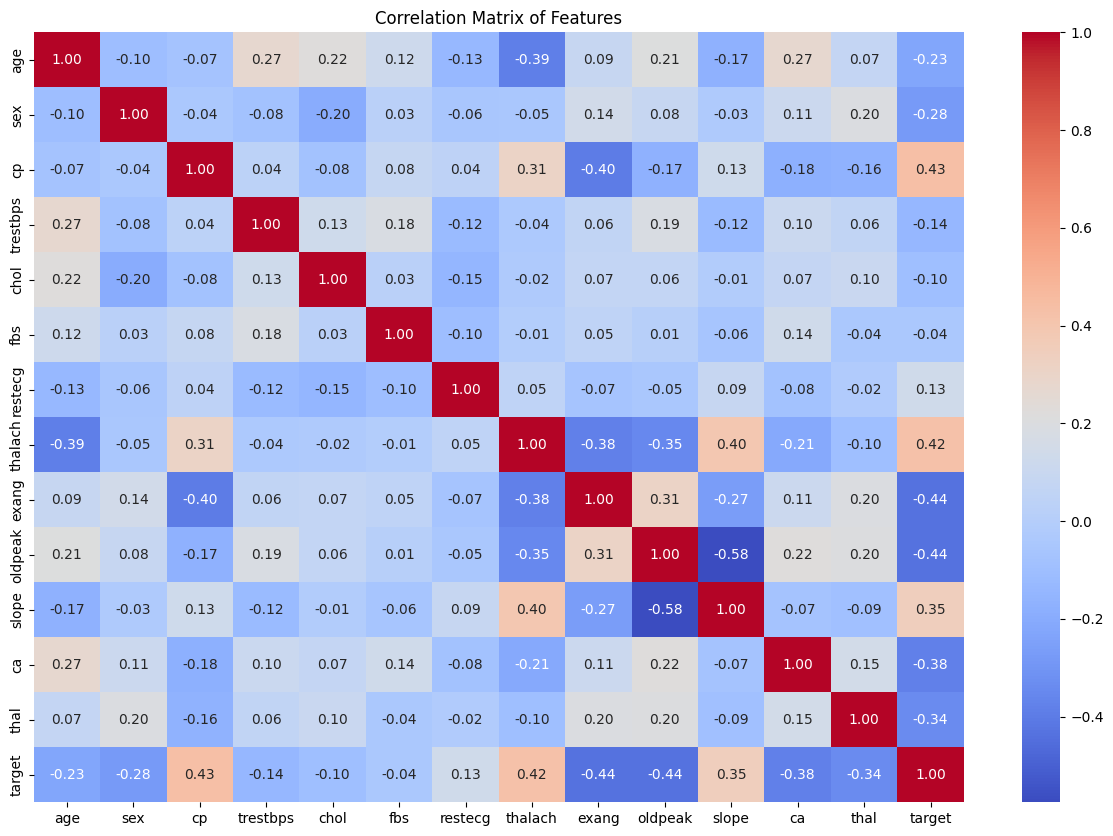

In [54]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [55]:
data['oldpeak'].skew()

np.float64(1.2108993882065326)

# Performing OHE,standardisation and transforming columns

In [56]:
x=data.iloc[:,0:13]
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


In [57]:
y=data.iloc[:,-1]
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
1020,1
1021,0
1022,0
1023,1


In [58]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=2,test_size=0.2)

In [59]:
numeric_skew=['trestbps','chol','oldpeak']
ohe=['cp','thal','restecg','slope']
only_numeric_scale=['age','trestbps','thalach','oldpeak']

In [60]:

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features_power_and_scale = ['trestbps', 'chol', 'oldpeak']
numerical_features_scale_only = ['age', 'thalach']


preprocessor = ColumnTransformer(
    transformers=[
        ('num_power_scale', Pipeline([
            ('power', PowerTransformer(method='yeo-johnson')),
            ('scaler', StandardScaler())
        ]), numerical_features_power_and_scale),
        ('num_scale', StandardScaler(), numerical_features_scale_only),
        ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_features)
    ],
    remainder='passthrough'
).set_output(transform='pandas')


pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(solver='liblinear'))
])

In [61]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_power_scale',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trestbps', 'chol',
                                                   'oldpeak']),
                                                 ('num_scale', StandardScaler(),
                                                  ['age', 'thalach']),
                                                 ('cat_ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('model', LogisticRegression(solver='liblinear'))])

In [62]:
y_pred=pipe.predict(x_test)

In [63]:
print(confusion_matrix)

<function confusion_matrix at 0x7863dddae0c0>


In [64]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.87      0.86      0.86       105
           1       0.85      0.86      0.86       100

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



In [65]:
import pickle
pickle.dump(data,open('data.pkl','wb'))
pickle.dump(pipe,open('pipe.pkl','wb'))